In [248]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [249]:
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

file_path = os.path.join(path, "btcusd_1-min_data.csv")

df = pd.read_csv(file_path)

print(df.head())

      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


In [250]:
print(df.shape, df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7470401 entries, 0 to 7470400
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 342.0 MB
(7470401, 6) None


In [251]:
df.isna().any()

Timestamp    False
Open         False
High         False
Low          False
Close        False
Volume       False
dtype: bool

In [252]:
sum(df["Close"]<0)

0

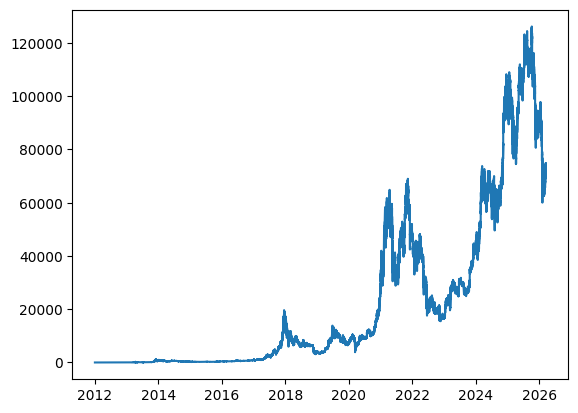

In [253]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"], unit="s")
plt.plot(df['Timestamp'], df['Close'])
plt.show()
# df['Close']=np.log(df['Close'])
# plt.plot(df['Timestamp'], df['Close'])
plt.show()

In [254]:
df["return"] = df["Close"].pct_change().shift(-1)
df.dropna()

,Timestamp,Open,High,Low,Close,Volume,return
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.000000,0.000000
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.000000,0.000000
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.000000,0.000000
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.000000,0.000000
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.000000,0.000000
...,...,...,...,...,...,...,...
7470395,2026-03-16 23:56:00,74781.00,74857.00,74781.00,74857.00,0.738303,0.000000
7470396,2026-03-16 23:57:00,74857.00,74857.00,74849.00,74857.00,0.207668,0.000134
7470397,2026-03-16 23:58:00,74869.00,74883.00,74867.00,74867.00,1.091984,0.000120
7470398,2026-03-16 23:59:00,74854.00,74888.00,74853.00,74876.00,0.891448,-0.002992


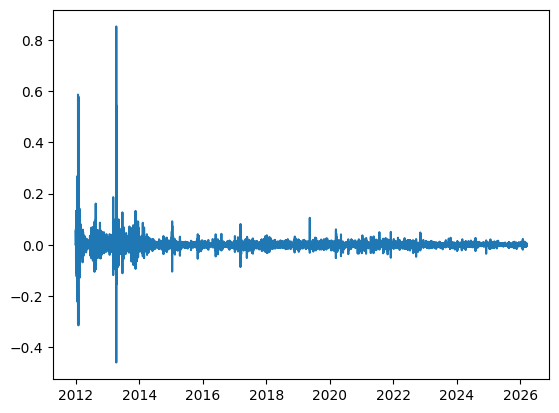

In [255]:
plt.plot(df['Timestamp'], df['return'])

In [256]:
df["return"] = df["return"].clip(-0.2, 0.2)

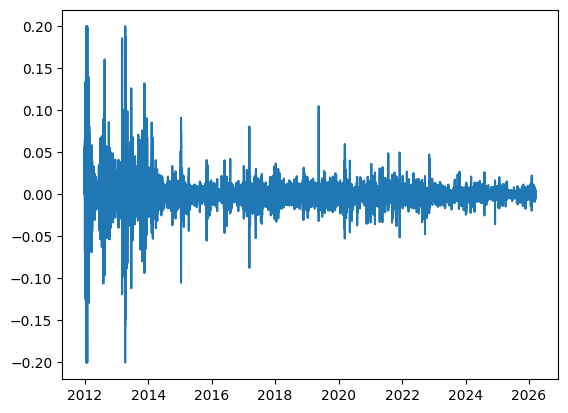

In [257]:
plt.plot(df['Timestamp'],df['return'])

In [266]:
print("mean of returns is equal", df["return"].mean(), " what is quite near to zero, \nstandard deviation is equal", df["return"].std(), "what is quite small and far from one, \nso after split data sets will be standardized")

mean of returns is equal 2.692642664736138e-06  what is quite near to zero, 
standard deviation is equal 0.0017156587230945694 what is quite small and far from one, 
so after split data sets will be standardized


In [259]:
split = int( len(df) * 0.8)
df.drop(columns=["Open",  "High",   "Low",  "Close",  "Volume"])
df_train = df[:split]
df_test = df[split:]

mu = df_train['return'].mean()
std = df_train['return'].std()

df_train['return'] = (df_train['return']-mu)/std
df_test['return'] = (df_test['return']-mu)/std

C:\Users\dbjd2\AppData\Local\Temp\ipykernel_24064\3125570185.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['return'] = (df_train['return']-mu)/std
C:\Users\dbjd2\AppData\Local\Temp\ipykernel_24064\3125570185.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['return'] = (df_test['return']-mu)/std


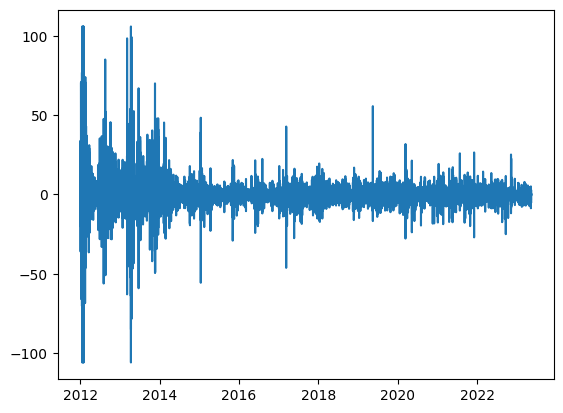

In [260]:
plt.plot(df_train['Timestamp'],df_train['return'])

In [261]:
df_train["volatility_10"] = df_train["return"].rolling(60*12).std()
df_train["return_mean_10"] = df_train["return"].rolling(60*12).mean()

C:\Users\dbjd2\AppData\Local\Temp\ipykernel_24064\4093467364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["volatility_10"] = df_train["return"].rolling(60*12).std()
C:\Users\dbjd2\AppData\Local\Temp\ipykernel_24064\4093467364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["return_mean_10"] = df_train["return"].rolling(60*12).mean()


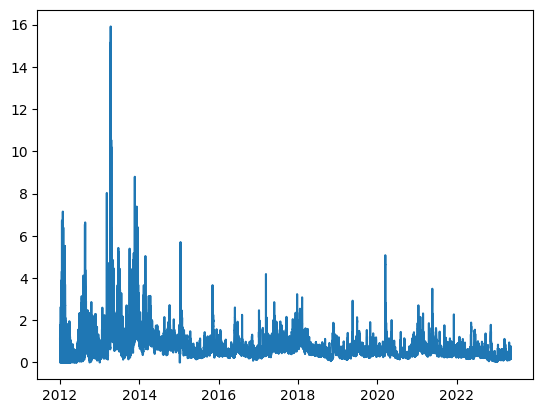

In [262]:
plt.plot(df_train["Timestamp"], df_train["volatility_10"])

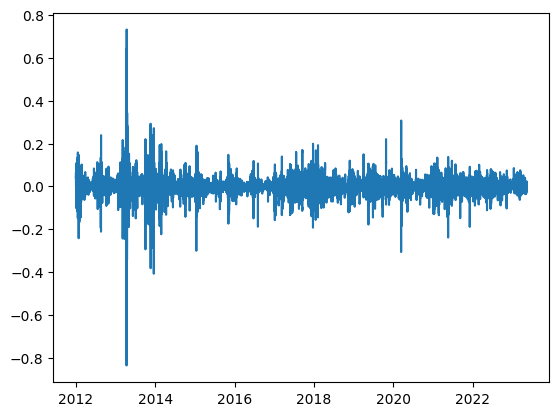

In [263]:
plt.plot(df_train["Timestamp"], df_train["return_mean_10"])